In [2]:
from pathlib import Path

import pandas as pd

# 数据路径
input_path = Path(
    r"D:\DesktopFile\26美赛\26\A dataset from the daily use of features in Android devices\Samsung\Dynamic\20220712\672d87e6755537a0\672d87e6755537a0_20220712_dynamic_processed.csv"
)

# 读取数据
df = pd.read_csv(input_path)

# 选择特征
selected_cols = [
    "timestamp",
    "screen_status",
    "bright_level",
    "battery_level",
    "battery_charging_status",
    "battery_current",
    "battery_voltage",
    "battery_power",
    "mobile_mode",
    "mobile_status",
    "mobile_rx",
    "mobile_tx",
    "wifi_status",
    "wifi_intensity",
    "wifi_speed",
    "wifi_rx",
    "wifi_tx",
    "cpu_usage",
    "frequency_core0",
    "frequency_core6",
]

missing = [c for c in selected_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

df_sel = df[selected_cols].copy()

# 处理移动网络模式的字符串值
df_sel["mobile_mode"] = df_sel["mobile_mode"].replace({"3G": 3, "4G": 4})

# 类型转换与归一化
df_sel["timestamp"] = pd.to_datetime(df_sel["timestamp"], errors="coerce")

numeric_cols = [c for c in selected_cols if c != "timestamp"]
for c in numeric_cols:
    df_sel[c] = pd.to_numeric(df_sel[c], errors="coerce")

df_sel["bright_level"] = df_sel["bright_level"] / 255.0
df_sel["cpu_usage"] = df_sel["cpu_usage"] / 100.0
df_sel["frequency_core0"] = df_sel["frequency_core0"] / 1804.8
df_sel["frequency_core6"] = df_sel["frequency_core6"] / 2208.0

# 保存处理后的数据
output_path = input_path.with_name(input_path.stem + "_selected.csv")
df_sel.to_csv(output_path, index=False)

# 预览
df_sel.head()



C:\Users\Zhurun Zhang\AppData\Local\Temp\ipykernel_21284\2693416920.py:11: DtypeWarning: Columns (0: mobile_mode) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_path)


,timestamp,screen_status,bright_level,battery_level,battery_charging_status,battery_current,battery_voltage,battery_power,mobile_mode,mobile_status,mobile_rx,mobile_tx,wifi_status,wifi_intensity,wifi_speed,wifi_rx,wifi_tx,cpu_usage,frequency_core0,frequency_core6
0,2022-07-12,0,0.160784,20,3,-0.959473,3.629000,-3.481928,0,0,0,0,1,-56,192,192,192,1.0,1.0,0.634783
1,2022-07-12,0,0.160784,20,3,-0.961609,3.641000,-3.501218,0,0,0,0,1,-56,192,192,192,1.0,1.0,1.000000
2,2022-07-12,0,0.160784,20,3,-0.961372,3.639667,-3.499075,0,0,0,0,1,-56,192,192,192,1.0,1.0,0.959420
3,2022-07-12,0,0.160784,20,3,-0.961134,3.638333,-3.496932,0,0,0,0,1,-56,192,192,192,1.0,1.0,0.918841
4,2022-07-12,0,0.160784,20,3,-0.960897,3.637000,-3.494788,0,0,0,0,1,-56,192,192,192,1.0,1.0,0.878261


In [3]:
print(len(df_sel))

86383


In [4]:
# 时间范围筛选
start_time = pd.Timestamp("2022-07-12 05:07:00")
end_time = pd.Timestamp("2022-07-12 13:24:00")

mask = (df_sel["timestamp"] >= start_time) & (df_sel["timestamp"] <= end_time)
df_time = df_sel[mask].copy()

# wifi_rx / wifi_tx 为 -1 的改为 0
for col in ["wifi_rx", "wifi_tx"]:
    if col in df_time.columns:
        df_time.loc[df_time[col] == -1, col] = 0

# 保存筛选后的数据
output_time_path = input_path.with_name(input_path.stem + "_selected_0506_1325.csv")
df_time.to_csv(output_time_path, index=False)

print(len(df_time))
df_time.head()


29869


,timestamp,screen_status,bright_level,battery_level,battery_charging_status,battery_current,battery_voltage,battery_power,mobile_mode,mobile_status,mobile_rx,mobile_tx,wifi_status,wifi_intensity,wifi_speed,wifi_rx,wifi_tx,cpu_usage,frequency_core0,frequency_core6
18419,2022-07-12 05:07:00,1,0.019608,99,3,-0.399170,4.36,-1.740381,0,0,0,0,1,-50,192,192,192,0.95,0.946809,0.939130
18420,2022-07-12 05:07:00,1,0.019608,99,3,-0.781860,4.36,-3.408910,0,0,0,0,1,-50,192,192,192,0.92,0.691489,1.000000
18421,2022-07-12 05:07:00,1,0.019608,99,3,-0.215149,4.36,-0.938050,0,0,0,0,1,-51,192,192,192,0.62,0.691489,0.965217
18422,2022-07-12 05:07:00,1,0.019608,99,3,-0.527954,4.36,-2.301879,0,0,0,0,1,-51,192,192,192,1.00,0.840426,1.000000
18423,2022-07-12 05:07:00,1,0.019608,99,3,-0.653992,4.36,-2.851405,0,0,0,0,1,-51,192,192,192,0.67,0.691489,0.939130


In [5]:
# import math
# import matplotlib.pyplot as plt
# import seaborn as sns

# # 使用 seaborn 风格与配色
# sns.set_theme(style="darkgrid")
# LEGEND_COLOR = "#c8c8e1"
# DARK_BLUE = "#526d9f"
# LIGHT_PURPLE = "#beaad1"
# LIGHT_ORANGE = "#F5C89A"
# DARK_ORANGE = "#C9896D"

# # 按时间排序，便于绘图
# df_time_plot = df_time.sort_values("timestamp").copy()

# # 需要绘制的列（除时间列）
# value_cols = [c for c in df_time_plot.columns if c != "timestamp"]

# # 每张图放 4 行子图
# rows_per_fig = 4
# for i in range(0, len(value_cols), rows_per_fig):
#     cols_chunk = value_cols[i : i + rows_per_fig]
#     fig, axes = plt.subplots(len(cols_chunk), 1, figsize=(12, 3 * len(cols_chunk)), sharex=True)
#     if len(cols_chunk) == 1:
#         axes = [axes]

#     for ax, col in zip(axes, cols_chunk):
#         sns.lineplot(
#             data=df_time_plot,
#             x="timestamp",
#             y=col,
#             ax=ax,
#             color=DARK_BLUE,
#             linewidth=0.6,
#         )
#         ax.set_title(col)
#         ax.set_xlim(
#             df_time_plot["timestamp"].iloc[0],
#             df_time_plot["timestamp"].iloc[-1],
#         )

#     axes[-1].set_xlabel("timestamp")
#     plt.tight_layout()
#     plt.show()


In [6]:
import numpy as np
import matplotlib.pyplot as plt

required_cols = [
    "battery_power",
    "cpu_usage",
    "frequency_core0",
    "frequency_core6",
    "screen_status",
    "bright_level",
    "mobile_status",
    "mobile_mode",
    "mobile_rx",
    "mobile_tx",
    "wifi_status",
    "wifi_intensity",
    "wifi_rx",
    "wifi_tx",
    "timestamp",
]

missing = [c for c in required_cols if c not in df_time.columns]
if missing:
    raise ValueError(f"df_time 缺少列: {missing}")

# 目标值（mW）：按秒计算（训练不取均值，评价再按分钟均值）
df_time_work = df_time.copy()
df_time_work["timestamp"] = pd.to_datetime(df_time_work["timestamp"], errors="coerce")
minute_key = df_time_work["timestamp"].dt.floor("min")
y_sec_raw = (df_time_work["battery_power"].abs() * 1000.0).astype(float)

# 常数项
P_gps = 50.0

y_sec = y_sec_raw - P_gps
# 特征列名（与系数一一对应）
# 分组顺序: Screen -> Proc -> Net -> Background
# GPS 为常数项 P_gps，不参与拟合
feature_names = [
    # --- Screen ---
    "P_screen_base",  # 屏幕点亮固定基线功耗
    "P_screen_bright",  # 屏幕亮度相关功耗（原P3）
    # --- Proc ---
    "P_cpu_little",  # CPU小核功耗（原P1）
    "P_cpu_big",  # CPU大核功耗（原P2）
    # --- Net (WiFi) ---
    "P_wifi_rx_low",  # WiFi接收-低信号（原Prx1_low）
    "P_wifi_tx_low",  # WiFi发送-低信号（原Ptx1_low）
    "P_wifi_base_low",  # WiFi基础-低信号（原P_b_low）
    "P_wifi_rx_high",  # WiFi接收-高信号（原Prx1_high）
    "P_wifi_tx_high",  # WiFi发送-高信号（原Ptx1_high）
    "P_wifi_base_high",  # WiFi基础-高信号（原P_b_high）
    # --- Net (Mobile) ---
    "P_mobile_rx",  # 移动网络接收（原Prx2）
    "P_mobile_tx",  # 移动网络发送（原Ptx2）
    "P_mobile_base",  # 移动网络基础（原Pa）
    # --- Background ---
    "P_background",  # 系统基础功耗（原P_base）
]

In [7]:
# 线性化特征矩阵（按秒，alpha1/alpha2 参与优化）
cpu_usage = df_time["cpu_usage"].astype(float)
freq_core0 = df_time["frequency_core0"].astype(float)
freq_core6 = df_time["frequency_core6"].astype(float)
screen_status = df_time["screen_status"].astype(float)
bright_level = df_time["bright_level"].astype(float)
mobile_status = df_time["mobile_status"].astype(float)
mobile_mode = df_time["mobile_mode"].astype(float)
mobile_rx = df_time["mobile_rx"].astype(float)
mobile_tx = df_time["mobile_tx"].astype(float)
wifi_status = df_time["wifi_status"].astype(float)
wifi_intensity = df_time["wifi_intensity"].astype(float)
wifi_rx = df_time["wifi_rx"].astype(float)
wifi_tx = df_time["wifi_tx"].astype(float)
mobile_mode_34 = np.where((mobile_mode == 3) | (mobile_mode == 4), 1.0, 0.0)
ones_col = np.ones(len(df_time_work), dtype=float)

alpha_min, alpha_max = 2, 3
iref_min, iref_max = -100.0, -80.0
iii = -55

i0_min, i0_max = -61, -52
k_min, k_max = 1.0, 20.0

# ---------------------------
def build_X_sec(alpha1, alpha2, i_ref, i0, k):
    tx_intensity_factor = np.power(10.0, (i_ref - wifi_intensity) / 10.0)
    z = (i0 - wifi_intensity) / k
    z = np.clip(z, -50.0, 50.0)
    w = 1.0 / (1.0 + np.exp(-z))
    wifi_low = wifi_status * w
    wifi_high = wifi_status * (1.0 - w)
    return np.column_stack(
        [
            # --- Screen ---
            screen_status,  # P_screen_base
            screen_status * (102.0 * bright_level * 0.3),  # P_screen_bright
            # --- Proc ---
            cpu_usage * (6.0 * np.power(freq_core0, alpha1)),  # P_cpu_little
            cpu_usage * (2.0 * np.power(freq_core6, alpha2)),  # P_cpu_big
            # --- Net (WiFi) ---
            wifi_low * wifi_rx,  # P_wifi_rx_low
            wifi_low * wifi_tx * tx_intensity_factor,  # P_wifi_tx_low
            wifi_low,  # P_wifi_base_low
            wifi_high * wifi_rx,  # P_wifi_rx_high
            wifi_high * wifi_tx,  # P_wifi_tx_high
            wifi_high,  # P_wifi_base_high
            # --- Net (Mobile) ---
            mobile_status * mobile_mode_34 * mobile_rx,  # P_mobile_rx
            mobile_status * mobile_mode_34 * mobile_tx,  # P_mobile_tx
            mobile_status * mobile_mode_34,  # P_mobile_base
            # --- Background ---
            ones_col,  # P_background
        ]
    )

# ---------------------------
# 构造秒级训练数据
mask_base = np.isfinite(y_sec) & minute_key.notna()

# 纯 numpy 投影梯度下降（非负约束）
def nnls_pgd(X_in, y_in, max_iter=10000, tol=1e-8):
    L = np.linalg.norm(X_in, "fro") ** 2 + 1e-12
    lr = 1.0 / L
    b = np.zeros(X_in.shape[1])
    for _ in range(max_iter):
        grad = X_in.T @ (X_in @ b - y_in)
        b_new = b - lr * grad
        b_new = np.maximum(b_new, 0.0)
        if np.linalg.norm(b_new - b) < tol * (np.linalg.norm(b) + 1e-12):
            b = b_new
            break
        b = b_new
    return b

def solve_nnls(X_in, y_in):
    try:
        from scipy.optimize import nnls

        params, _ = nnls(X_in, y_in)
        method = "scipy.nnls"
    except Exception:
        params = nnls_pgd(X_in, y_in)
        method = "pgd"
    return np.maximum(params, 1e-12), method

def build_minute_agg(X_sec_in, y_sec_in, minute_key_in):
    df_X = pd.DataFrame(X_sec_in)
    df_X["timestamp"] = minute_key_in
    X_min_df = df_X.groupby("timestamp", as_index=False).mean()
    y_min_df = (
        pd.DataFrame({"timestamp": minute_key_in, "y": y_sec_in})
        .groupby("timestamp", as_index=False)
        .mean()
    )
    min_df = y_min_df.merge(X_min_df, on="timestamp", how="inner")
    y_min = min_df["y"].to_numpy()
    X_min = min_df.drop(columns=["timestamp", "y"]).to_numpy()
    return X_min, y_min
# 构造秒级训练数据

def eval_params(alpha1, alpha2, i_ref, i0, k, fit_mode, sample_idx=None):
    X_tmp = build_X_sec(alpha1, alpha2, i_ref, i0, k)
    if sample_idx is None:
        mask_tmp = mask_base & np.isfinite(X_tmp).all(axis=1)
        if mask_tmp.sum() < 10:
            return np.inf, None, None, None, None, None, None
        X_sec_valid = X_tmp[mask_tmp]
        y_sec_valid = y_sec[mask_tmp]
        minute_key_valid = minute_key[mask_tmp].to_numpy()
        X_sec_full = X_tmp
        mask_full = mask_tmp
    else:
        X_s = X_tmp[sample_idx]
        y_s = y_sec.iloc[sample_idx].to_numpy()
        minute_key_s = minute_key.iloc[sample_idx].to_numpy()
        mask_s = np.isfinite(y_s) & np.isfinite(X_s).all(axis=1) & pd.notna(minute_key_s)
        if mask_s.sum() < 10:
            return np.inf, None, None, None, None, None, None
        X_sec_valid = X_s[mask_s]
        y_sec_valid = y_s[mask_s]
        minute_key_valid = minute_key_s[mask_s]
        X_sec_full = None
        mask_full = None
    if fit_mode == "sec":
        X_fit, y_fit = X_sec_valid, y_sec_valid
    elif fit_mode == "min":
        X_fit, y_fit = build_minute_agg(X_sec_valid, y_sec_valid, minute_key_valid)
        if len(y_fit) < 5:
            return np.inf, None, None, None, None, None, None
    else:
        raise ValueError("fit_mode 必须是 'sec' 或 'min'")

    params_tmp, coef_method_tmp = solve_nnls(X_fit, y_fit)
    y_pred_tmp = X_fit @ params_tmp
    mse_tmp = np.mean((y_fit - y_pred_tmp) ** 2)
    return mse_tmp, params_tmp, coef_method_tmp, mask_full, X_sec_full, X_fit, y_fit


def optimize_params(fit_mode, sample_idx=None, use_global=True, x0=None):
    def objective(a):
        mse_tmp, _, _, _, _, _, _ = eval_params(
            a[0], a[1], a[2], a[3], a[4], fit_mode, sample_idx
        )
        return mse_tmp

    bounds = [
        (alpha_min, alpha_max),
        (alpha_min, alpha_max),
        (iref_min, iref_max),
        (i0_min, i0_max),
        (k_min, k_max),
    ]
    if x0 is None:
        x0 = np.array([2.5, 2.5, -80.0, iii, 10.0])

    if use_global:
        try:
            from scipy.optimize import differential_evolution, minimize

            res = differential_evolution(
                objective,
                bounds=bounds,
                seed=42,
                polish=True,
            )
            alpha1_opt, alpha2_opt, i_ref_opt, i0_opt, k_opt = res.x
            alpha_method = "scipy.differential_evolution"

            if res.success:
                res_local = minimize(
                    objective,
                    x0=res.x,
                    bounds=bounds,
                    method="L-BFGS-B",
                )
                if res_local.success and res_local.fun <= res.fun:
                    alpha1_opt, alpha2_opt, i_ref_opt, i0_opt, k_opt = res_local.x
                    alpha_method += "+L-BFGS-B"
            else:
                alpha_method += "(未完全收敛)"
            return alpha1_opt, alpha2_opt, i_ref_opt, i0_opt, k_opt, alpha_method
        except Exception:
            pass

    try:
        from scipy.optimize import minimize

        res = minimize(
            objective,
            x0=x0,
            bounds=bounds,
            method="L-BFGS-B",
        )
        alpha1_opt, alpha2_opt, i_ref_opt, i0_opt, k_opt = res.x
        alpha_method = "scipy.minimize(L-BFGS-B)" if use_global else "local.minimize(L-BFGS-B)"
        if not res.success:
            alpha_method += "(未完全收敛)"
    except Exception:
        alpha_grid = np.linspace(alpha_min, alpha_max, 13)
        iref_grid = np.linspace(iref_min, iref_max, 7)
        i0_grid = np.linspace(i0_min, i0_max, 5)
        k_grid = np.linspace(k_min, k_max, 5)
        best = {
            "mse": np.inf,
            "alpha1": None,
            "alpha2": None,
            "i_ref": None,
            "i0": None,
            "k": None,
        }
        for a1 in alpha_grid:
            for a2 in alpha_grid:
                for i_ref in iref_grid:
                    for i0 in i0_grid:
                        for k in k_grid:
                            mse_tmp, _, _, _, _, _, _ = eval_params(
                                a1, a2, i_ref, i0, k, fit_mode, sample_idx
                            )
                            if mse_tmp < best["mse"]:
                                best = {
                                    "mse": mse_tmp,
                                    "alpha1": a1,
                                    "alpha2": a2,
                                    "i_ref": i_ref,
                                    "i0": i0,
                                    "k": k,
                                }
        alpha1_opt = best["alpha1"]
        alpha2_opt = best["alpha2"]
        i_ref_opt = best["i_ref"]
        i0_opt = best["i0"]
        k_opt = best["k"]
        alpha_method = (
            f"grid_search({len(alpha_grid)}x{len(alpha_grid)}x{len(iref_grid)}x"
            f"{len(i0_grid)}x{len(k_grid)})"
        )
    return alpha1_opt, alpha2_opt, i_ref_opt, i0_opt, k_opt, alpha_method

# ---------------------------

param_names = feature_names + ["alpha1", "alpha2", "i_ref", "i0", "k"]


def fit_model(fit_mode, sample_idx=None, use_global=True, x0=None):
    alpha1_opt, alpha2_opt, i_ref_opt, i0_opt, k_opt, alpha_method = optimize_params(
        fit_mode, sample_idx=sample_idx, use_global=use_global, x0=x0
    )

    mse_final, params, coef_method, mask_train, X_sec, X_fit, y_fit = eval_params(
        alpha1_opt, alpha2_opt, i_ref_opt, i0_opt, k_opt, fit_mode, sample_idx=sample_idx
    )

    if params is None:
        raise ValueError("可用训练样本过少或无法拟合")

    method = f"fit={fit_mode}, alpha={alpha_method}, coef={coef_method}"

    param_values = np.concatenate([params, [alpha1_opt, alpha2_opt, i_ref_opt, i0_opt, k_opt]])
    result = pd.DataFrame({"param": param_names, "value": param_values})

    return {
        "fit_mode": fit_mode,
        "params": params,
        "alpha1": alpha1_opt,
        "alpha2": alpha2_opt,
        "i_ref": i_ref_opt,
        "i0": i0_opt,
        "k": k_opt,
        "param_values": param_values,
        "result": result,
        "method": method,
        "mask_train": mask_train,
        "X_sec": X_sec,
        "X_fit": X_fit,
        "y_fit": y_fit,
    }


fit_sec = fit_model("sec", use_global=True)
fit_min = fit_model("min", use_global=True)

result_sec = fit_sec["result"]
result_min = fit_min["result"]
result = result_sec

In [8]:
# 预测与评价（先按秒预测，再按分钟平均）
def eval_minute_metrics(X_sec_in, params_in, mask_sec_in):
    mask = mask_sec_in
    y_pred_sec = X_sec_in[mask] @ params_in + P_gps
    y_true_sec = y_sec[mask]

    minute_key_masked = minute_key[mask].to_numpy()
    min_df = pd.DataFrame(
        {
            "timestamp": minute_key_masked,
            "y_true": y_true_sec,
            "y_pred": y_pred_sec,
        }
    ).groupby("timestamp", as_index=False).mean()
    min_df = min_df.dropna(subset=["y_true", "y_pred"])

    y_true = min_df["y_true"].to_numpy()
    y_pred = min_df["y_pred"].to_numpy()

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)

    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred) ** 2)
    return r2, mae, mse, min_df, y_true, y_pred

# ---------------------------
def calc_standard_error(X_fit_in, y_fit_in, params_in):
    n, p = X_fit_in.shape
    if n <= p:
        return np.full(p, np.nan)
    resid = y_fit_in - X_fit_in @ params_in
    sigma2 = (resid @ resid) / max(n - p, 1)
    XtX_inv = np.linalg.pinv(X_fit_in.T @ X_fit_in)
    return np.sqrt(np.diag(XtX_inv) * sigma2)

def bootstrap_full_params(fit_mode, base_fit, n_boot=0, seed=42):
    if n_boot <= 0:
        return None, None, None, None
    rng = np.random.default_rng(seed)
    valid_idx = np.where(mask_base)[0]
    boot_params = np.zeros((n_boot, len(param_names)))
    boot_mae = np.zeros(n_boot)
    x0 = np.array([
        base_fit["alpha1"],
        base_fit["alpha2"],
        base_fit["i_ref"],
        base_fit["i0"],
        base_fit["k"],
    ])

    for i in range(n_boot):
        sample_idx = rng.choice(valid_idx, size=len(valid_idx), replace=True)
        fit_b = fit_model(fit_mode, sample_idx=sample_idx, use_global=False, x0=x0)
        boot_params[i] = fit_b["param_values"]
        # 用 bootstrap 的非线性参数重新构建 X_sec，在原始数据上计算 MAE
        X_sec_b = build_X_sec(fit_b["alpha1"], fit_b["alpha2"], fit_b["i_ref"], fit_b["i0"], fit_b["k"])
        r2_b, mae_b, mse_b, _, _, _ = eval_minute_metrics(
            X_sec_b, fit_b["params"], base_fit["mask_train"]
        )
        boot_mae[i] = mae_b

    se_boot = boot_params.std(axis=0, ddof=1)
    # 计算95%置信区间 (百分位数法)
    ci_lower = np.percentile(boot_params, 2.5, axis=0)
    ci_upper = np.percentile(boot_params, 97.5, axis=0)
    ci_95 = np.column_stack([ci_lower, ci_upper])
    
    # 构建包含每组参数和MAE的DataFrame
    boot_df = pd.DataFrame(boot_params, columns=param_names)
    boot_df["MAE"] = boot_mae
    
    return se_boot, boot_params, ci_95, boot_df

# ---------------------------
def attach_metrics(fit_in):
    r2, mae, mse, min_df, y_true, y_pred = eval_minute_metrics(
        fit_in["X_sec"], fit_in["params"], fit_in["mask_train"]
    )
    fit_in["metrics"] = {"r2": r2, "mae": mae, "mse": mse}
    fit_in["min_df"] = min_df
    fit_in["y_true"] = y_true
    fit_in["y_pred"] = y_pred
    return fit_in


fit_sec = attach_metrics(fit_sec)
fit_min = attach_metrics(fit_min)


def print_fit_summary(title, fit_in, se_linear, se_full=None, ci_95=None):
    print(f"===== {title} =====")
    print(f"拟合方法: {fit_in['method']}")
    print(fit_in["result"].to_string(index=False))
    # print("线性参数标准误(近似):")
    # se_df = pd.DataFrame({"param": feature_names, "se": se_linear})
    # print(se_df.to_string(index=False))
    if se_full is not None:
        print("参数标准误及95%置信区间(bootstrap, 含alpha/i_ref/i0/k):")
        if ci_95 is not None:
            se_full_df = pd.DataFrame({
                "param": param_names, 
                "se_boot": se_full,
                "CI_2.5%": ci_95[:, 0],
                "CI_97.5%": ci_95[:, 1]
            })
        else:
            se_full_df = pd.DataFrame({"param": param_names, "se_boot": se_full})
        print(se_full_df.to_string(index=False))
    print(f"R^2: {fit_in['metrics']['r2']:.4f}")
    print(f"MAE: {fit_in['metrics']['mae']:.4f}")
    print(f"MSE: {fit_in['metrics']['mse']:.4f}")


In [67]:
#se_linear_sec = calc_standard_error(fit_sec["X_fit"], fit_sec["y_fit"], fit_sec["params"])
se_linear_min = calc_standard_error(fit_min["X_fit"], fit_min["y_fit"], fit_min["params"])

n_boot_full = 1000
#se_full_sec, boot_params_sec, ci_95_sec, boot_df_sec = bootstrap_full_params("sec", fit_sec, n_boot=n_boot_full, seed=42)
se_full_min, boot_params_min, ci_95_min, boot_df_min = bootstrap_full_params("min", fit_min, n_boot=n_boot_full, seed=42)

#print_fit_summary("秒级拟合", fit_sec, se_linear_sec, se_full_sec, ci_95_sec)
print_fit_summary("分钟均值拟合", fit_min, se_linear_min, se_full_min, ci_95_min)


min_df = fit_min["min_df"]
y_true = fit_min["y_true"]
y_pred = fit_min["y_pred"]



===== 分钟均值拟合 =====
拟合方法: fit=min, alpha=scipy.differential_evolution+L-BFGS-B, coef=scipy.nnls
           param         value
   P_screen_base  5.175599e+02
 P_screen_bright  6.465153e+01
    P_cpu_little  6.580234e+01
       P_cpu_big  1.401494e+03
   P_wifi_rx_low  1.000000e-12
   P_wifi_tx_low  2.712433e+02
 P_wifi_base_low  1.000000e-12
  P_wifi_rx_high  1.000000e-12
  P_wifi_tx_high  1.000000e-12
P_wifi_base_high  4.186289e+02
     P_mobile_rx  1.000000e-12
     P_mobile_tx  1.437823e-03
   P_mobile_base  5.520806e+02
    P_background  2.520338e+02
          alpha1  3.000000e+00
          alpha2  2.000000e+00
           i_ref -9.070260e+01
              i0 -5.515700e+01
               k  1.000000e+00
参数标准误及95%置信区间(bootstrap, 含alpha/i_ref/i0/k):
           param      se_boot       CI_2.5%      CI_97.5%
   P_screen_base 1.850676e+01  4.899160e+02  5.612798e+02
 P_screen_bright 1.521432e+00  6.157618e+01  6.756941e+01
    P_cpu_little 9.765406e+00  3.492010e+01  7.279620e+01
       P

In [ ]:
import math
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors

# 输入
K = 0
_df = boot_df_min.copy()

# 若未提前定义 group_cols，则按默认参数名构造
if "group_cols" in globals():
    _group_cols = group_cols
else:
    _group_cols = {
        "Screen": ["P_screen_base", "P_screen_bright"],
        "Proc": ["P_cpu_little", "P_cpu_big"],
        "Net": [
            "P_wifi_rx_low",
            "P_wifi_tx_low",
            "P_wifi_base_low",
            "P_wifi_rx_high",
            "P_wifi_tx_high",
            "P_wifi_base_high",
            "P_mobile_rx",
            "P_mobile_tx",
            "P_mobile_base",
        ],
        "GPS": ["P_gps"],
        "Background": ["P_background"],
    }

# 只保留在数据中存在的列，并检查缺失
missing = {}
for g, cols in _group_cols.items():
    present = [c for c in cols if c in _df.columns]
    missing_cols = [c for c in cols if c not in _df.columns]
    _group_cols[g] = present
    if missing_cols:
        missing[g] = missing_cols

# GPS 若为常数且不在数据中，则直接忽略该组
if "GPS" in missing and missing["GPS"] == ["P_gps"]:
    _group_cols.pop("GPS", None)
    missing.pop("GPS", None)

if missing:
    raise ValueError(f"boot_df_min 缺少分组参数列: {missing}")

group_names = list(_group_cols.keys())
M = len(group_names)
if M == 0:
    raise ValueError("group_cols 不能为空")

param_cols = []
for g in group_names:
    param_cols.extend(_group_cols[g])
# 去重并保持顺序
param_cols = list(dict.fromkeys(param_cols))

# 目标列：优先 y，其次 MAE（不区分大小写）
if "y" in _df.columns:
    y_col = "y"
else:
    cols_lower = {c.lower(): c for c in _df.columns}
    if "mae" in cols_lower:
        y_col = cols_lower["mae"]
    else:
        raise ValueError("boot_df_min 中未找到列 y 或 MAE")

y = _df[y_col].to_numpy()
B = len(_df)

# z-score 标准化
means = _df[param_cols].mean()
stds = _df[param_cols].std(ddof=0).replace(0, 1.0)
Z = (_df[param_cols] - means) / stds

# 子集 -> 方差 v(S)
max_neighbors = max(B - 1, 1)
K_eff = min(K, max_neighbors)

v_dict = {}

for mask in range(1 << M):
    if mask == 0:
        m = np.full(B, y.mean())
    else:
        cols = []
        for i, g in enumerate(group_names):
            if mask & (1 << i):
                cols.extend(_group_cols[g])
        X = Z[cols].to_numpy()
        if B <= 1:
            m = np.full(B, y.mean())
        else:
            nn = NearestNeighbors(n_neighbors=K_eff + 1, metric="euclidean")
            nn.fit(X)
            idx = nn.kneighbors(X, return_distance=False)
            # 常规情况下自身在第一位
            if np.all(idx[:, 0] == np.arange(B)):
                neigh = idx[:, 1: K_eff + 1]
            else:
                # 保险处理：去掉自身索引
                self_mask = idx == np.arange(B)[:, None]
                idx_no_self = np.where(self_mask, -1, idx)
                order = np.argsort(idx_no_self == -1, axis=1)
                sorted_idx = np.take_along_axis(idx_no_self, order, axis=1)
                neigh = sorted_idx[:, :K_eff]
            m = y[neigh].mean(axis=1)

    v = float(np.var(m, ddof=1)) if B > 1 else 0.0
    v_dict[mask] = v

var_y = float(np.var(y, ddof=1)) if B > 1 else 0.0

# Shapley values
fact = math.factorial
M_fact = fact(M)
phi = {}

for k in range(M):
    phi_k = 0.0
    for mask in range(1 << M):
        if mask & (1 << k):
            continue
        s_size = bin(mask).count("1")
        w = fact(s_size) * fact(M - s_size - 1) / M_fact
        v_with = v_dict[mask | (1 << k)]
        v_without = v_dict[mask]
        phi_k += w * (v_with - v_without)
    phi[group_names[k]] = phi_k

if var_y > 0:
    shapley_effect = {g: phi[g] / var_y for g in group_names}
else:
    shapley_effect = {g: np.nan for g in group_names}

result = pd.DataFrame({
    "group": group_names,
    "shapley_effect": [shapley_effect[g] for g in group_names],
    "phi": [phi[g] for g in group_names],
})

result["var_y"] = var_y
result["sum_shapley"] = result["shapley_effect"].sum()



In [24]:
result

,group,shapley_effect,phi,var_y,sum_shapley
0,Screen,0.014950,0.037491,2.507761,0.207063
1,Proc,0.068600,0.172031,2.507761,0.207063
2,Net,0.097602,0.244763,2.507761,0.207063
3,Background,0.025912,0.064980,2.507761,0.207063


In [ ]:
# 绘图已合并到下一个单元


分钟预测已保存: D:\DesktopFile\26美赛\26\A dataset from the daily use of features in Android devices\Samsung\Dynamic\20220712\672d87e6755537a0\672d87e6755537a0_20220712_dynamic_processed_selected_0506_1325_pred_minute.csv
预测时间范围: 2022-07-12 05:07:00 ~ 2022-07-12 13:24:00
P_base分钟统计:
count    4.980000e+02
mean     2.520338e+02
std      2.845029e-14
min      2.520338e+02
25%      2.520338e+02
50%      2.520338e+02
75%      2.520338e+02
max      2.520338e+02
Name: P_base, dtype: float64


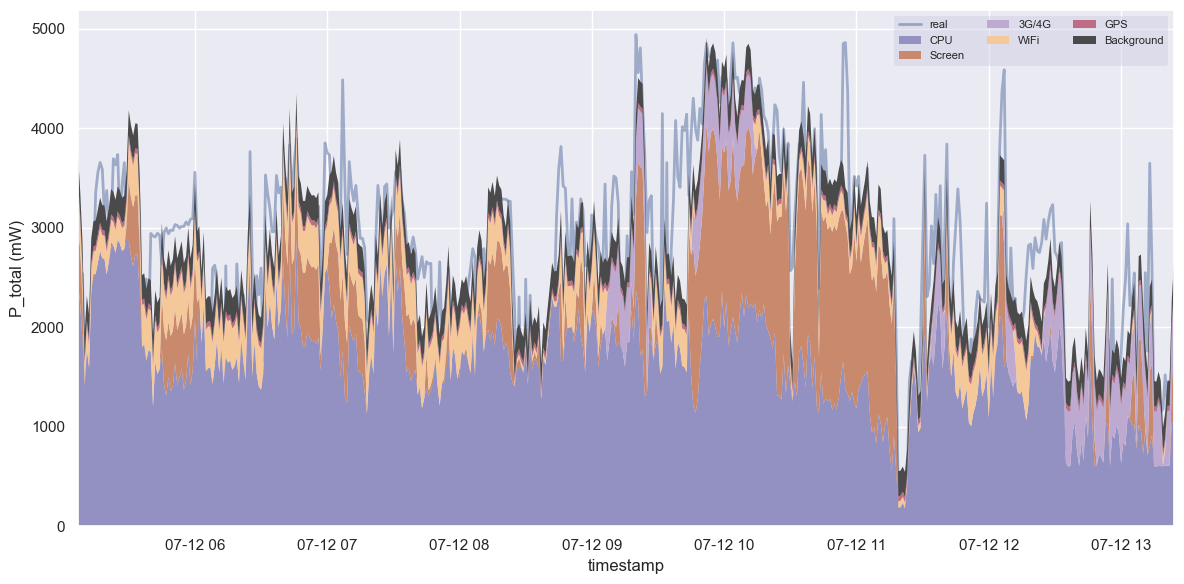

In [64]:


min_pred_df = (
    min_df[["timestamp", "y_pred"]]
    .sort_values("timestamp")
    .rename(columns={"y_pred": "P_pred"})
)
if min_pred_df.empty:
    raise ValueError("分钟级预测结果为空，无法保存")

if "output_time_path" in globals():
    output_pred_path = output_time_path.with_name(output_time_path.stem + "_pred_minute.csv")
elif "input_path" in globals():
    output_pred_path = input_path.with_name(input_path.stem + "_pred_minute.csv")
else:
    output_pred_path = "minute_pred.csv"

min_pred_df.to_csv(output_pred_path, index=False)
start_ts = min_pred_df["timestamp"].iloc[0]
end_ts = min_pred_df["timestamp"].iloc[-1]
print(f"分钟预测已保存: {output_pred_path}")
print(f"预测时间范围: {start_ts} ~ {end_ts}")

# 各模块功率分解（先按秒，再按分钟平均）
plot_mode = globals().get("plot_mode", "min")
if plot_mode == "sec":
    fit_decomp = fit_sec
elif plot_mode == "min":
    fit_decomp = fit_min
else:
    raise ValueError("plot_mode 只能是 'sec' 或 'min'")

X_sec = fit_decomp["X_sec"]
mask_sec = fit_decomp["mask_train"]
params = fit_decomp["params"]
if X_sec is None or mask_sec is None:
    raise ValueError("缺少用于分解的秒级数据，请重新运行拟合单元")

minute_key_masked = minute_key[mask_sec].to_numpy()
X_sec_masked = X_sec[mask_sec]
feat_idx = {name: i for i, name in enumerate(feature_names)}

comp_sec_df = pd.DataFrame(
    {
        "timestamp": minute_key_masked,
        "P_cpu": params[feat_idx["P_cpu_little"]] * X_sec_masked[:, feat_idx["P_cpu_little"]]
        + params[feat_idx["P_cpu_big"]] * X_sec_masked[:, feat_idx["P_cpu_big"]],
        "P_screen": params[feat_idx["P_screen_base"]]
        * X_sec_masked[:, feat_idx["P_screen_base"]]
        + params[feat_idx["P_screen_bright"]] * X_sec_masked[:, feat_idx["P_screen_bright"]],
        "P_wifi": params[feat_idx["P_wifi_rx_low"]] * X_sec_masked[:, feat_idx["P_wifi_rx_low"]]
        + params[feat_idx["P_wifi_tx_low"]] * X_sec_masked[:, feat_idx["P_wifi_tx_low"]]
        + params[feat_idx["P_wifi_base_low"]] * X_sec_masked[:, feat_idx["P_wifi_base_low"]]
        + params[feat_idx["P_wifi_rx_high"]] * X_sec_masked[:, feat_idx["P_wifi_rx_high"]]
        + params[feat_idx["P_wifi_tx_high"]] * X_sec_masked[:, feat_idx["P_wifi_tx_high"]]
        + params[feat_idx["P_wifi_base_high"]] * X_sec_masked[:, feat_idx["P_wifi_base_high"]],
        "P_cell": params[feat_idx["P_mobile_rx"]] * X_sec_masked[:, feat_idx["P_mobile_rx"]]
        + params[feat_idx["P_mobile_tx"]] * X_sec_masked[:, feat_idx["P_mobile_tx"]]
        + params[feat_idx["P_mobile_base"]] * X_sec_masked[:, feat_idx["P_mobile_base"]],
        "P_base": params[feat_idx["P_background"]] * X_sec_masked[:, feat_idx["P_background"]],
        "P_gps": np.full(mask_sec.sum(), P_gps, dtype=float),
    }
)

comp_min_df = (
    comp_sec_df.groupby("timestamp", as_index=False)
    .mean()
    .sort_values("timestamp")
)

import seaborn as sns

sns.set_theme(style="darkgrid")
LEGEND_COLOR = "#c8c8e1"
DARK_BLUE = "#526d9f"
LIGHT_PURPLE = "#beaad1"
LIGHT_ORANGE = "#F5C89A"
DARK_ORANGE = "#C9896D"
GREEN = "#c06c84"
REAL_LINE_COLOR = "#4a4a4a"

plot_df = min_df.sort_values("timestamp")

comp_min_df["P_mobile"] = comp_min_df["P_cell"]

comp_cols = ["P_cpu", "P_screen", "P_mobile", "P_wifi", "P_gps", "P_base"]
comp_labels = ["CPU", "Screen", "3G/4G", "WiFi", "GPS", "Background"]
comp_min_df["P_pred_sum"] = comp_min_df[comp_cols].sum(axis=1)

print("P_base分钟统计:")
print(comp_min_df["P_base"].describe())

# 面积图：拟合曲线下各模块功率占比 + 真实曲线
fig2, ax2 = plt.subplots(1, 1, figsize=(12, 6), sharex=False)
comp_color_map = {
    "CPU": "#9291c2",
    "Screen": DARK_ORANGE,
    "3G/4G": LIGHT_PURPLE,
    "WiFi": LIGHT_ORANGE,
    "GPS": GREEN,
    "Background": real_line_color,
}
stack_colors = [comp_color_map[label] for label in comp_labels]
real_line_color = REAL_LINE_COLOR

ax2.plot(
    plot_df["timestamp"],
    plot_df["y_true"],
    color=DARK_BLUE,
    linewidth=2,
    label="real",
    alpha=0.5,
    zorder=1,
)

ax2.stackplot(
    comp_min_df["timestamp"],
    [comp_min_df[c] for c in comp_cols],
    labels=comp_labels,
    colors=stack_colors,
    edgecolor="none",
    alpha=1,
    zorder=2,
)

ax2.set_xlabel("timestamp")
ax2.set_ylabel("P_total (mW)")
ax2.set_xlim(start_ts, end_ts)
ax2.margins(x=0)
ax2.legend(
    ncol=3,
    fontsize=8,
    title=None,
    facecolor=LEGEND_COLOR,
    edgecolor="none",
    framealpha=0.4,
)

plt.tight_layout()
plt.show()


In [ ]:
# 蒙特卡洛参数采样与功率曲线生成
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) 依据当前参数均值与方差设定分布
if "boot_params_min" in globals() and boot_params_min is not None:
    param_mean = np.nanmean(boot_params_min, axis=0)
    param_var = np.nanvar(boot_params_min, axis=0, ddof=1)
    stats_source = "boot_params_min"

param_var = np.where(param_var < 1e-12, 0.0, param_var)

# 固定部分参数不采样
fixed_names = ["i_ref", "i0", "alpha1", "alpha2"]
for name in fixed_names:
    if name in param_names:
        param_var[param_names.index(name)] = 0.0

print(f"参数统计来源: {stats_source}")

param_std = np.sqrt(np.maximum(param_var, 0.0))
param_std_base = param_std.copy()

# 2) 设置参数区间约束
idx_map = {name: i for i, name in enumerate(param_names)}
low = np.zeros(len(param_names), dtype=float)
high = np.full(len(param_names), np.inf, dtype=float)

# 非线性参数区间
low[idx_map["alpha1"]] = alpha_min
high[idx_map["alpha1"]] = alpha_max
low[idx_map["alpha2"]] = alpha_min
high[idx_map["alpha2"]] = alpha_max
low[idx_map["i_ref"]] = iref_min
high[idx_map["i_ref"]] = iref_max
low[idx_map["i0"]] = i0_min
high[idx_map["i0"]] = i0_max
low[idx_map["k"]] = k_min
high[idx_map["k"]] = k_max

# 3) 采样函数（截断正态，超界则重采样，最多尝试 100 次）
_rng = np.random.default_rng(42)

def sample_trunc_normal(mean, std, lo, hi):
    if not np.isfinite(std) or std <= 0:
        return float(np.clip(mean, lo, hi))
    val = mean
    for _ in range(100):
        val = _rng.normal(mean, std)
        ok_lo = (not np.isfinite(lo)) or (val >= lo)
        ok_hi = (not np.isfinite(hi)) or (val <= hi)
        if ok_lo and ok_hi:
            return float(val)
    return float(np.clip(val, lo, hi))

# 4) 蒙特卡洛生成 100 组参数
n_mc = 100
param_samples = np.zeros((n_mc, len(param_names)))
for i in range(n_mc):
    for j in range(len(param_names)):
        param_samples[i, j] = sample_trunc_normal(param_mean[j], param_std[j], low[j], high[j])

# 5) 代入原始数据，生成 100 条总功率曲线（秒级）
num_rows = len(df_time_work)
pred_curves = np.full((num_rows, n_mc), np.nan, dtype=float)

for i in range(n_mc):
    p = param_samples[i]
    coef = p[: len(feature_names)]
    alpha1 = p[idx_map["alpha1"]]
    alpha2 = p[idx_map["alpha2"]]
    i_ref = p[idx_map["i_ref"]]
    i0 = p[idx_map["i0"]]
    k = p[idx_map["k"]]

    X_all = build_X_sec(alpha1, alpha2, i_ref, i0, k)
    mask_pred = np.isfinite(X_all).all(axis=1)
    y_pred = np.full(num_rows, np.nan, dtype=float)
    y_pred[mask_pred] = X_all[mask_pred] @ coef + P_gps
    pred_curves[:, i] = y_pred

# 真实总功率（mW）
if "y_sec_raw" in globals():
    y_true_total = y_sec_raw.to_numpy()
else:
    y_true_total = (y_sec + P_gps).to_numpy()

# 6) 过滤：最大功率不能超过 5000
max_per_curve = np.nanmax(pred_curves, axis=0)
valid_mask = max_per_curve <= 10000
pred_curves_f = pred_curves[:, valid_mask]
param_samples_f = param_samples[valid_mask]

n_valid = pred_curves_f.shape[1]
print(f"满足最大功率<=5000的曲线数: {n_valid}/{n_mc}")

# 7) 随机选几组与真实值一起画图
if n_valid > 0:
    plot_k = min(5, n_valid)
    sel = _rng.choice(n_valid, size=plot_k, replace=False)

    plt.figure(figsize=(12, 4))
    for i in sel:
        plt.plot(df_time_work["timestamp"], pred_curves_f[:, i], alpha=0.6, label=f"MC_{i:03d}")
    plt.plot(df_time_work["timestamp"], y_true_total, color="black", linewidth=1.2, label="真实值")
    plt.xlabel("timestamp")
    plt.ylabel("power (mW)")
    plt.legend(ncol=3)
    plt.tight_layout()
else:
    print("没有曲线满足最大功率<=5000，跳过绘图。")

# 8) 保存到 CSV（每列是一组参数对应的总功率曲线）
if n_valid > 0:
    col_names = [f"mc_{i:03d}" for i in range(n_valid)]
    curve_df = pd.DataFrame(pred_curves_f, columns=col_names)

    if "input_path" in globals():
        out_dir = os.path.dirname(input_path)
    else:
        out_dir = os.getcwd()

    out_path = os.path.join(out_dir, "mc_power_curves.csv")
    curve_df.to_csv(out_path, index=False)
    print(f"已保存: {out_path}")
else:
    print("没有曲线满足最大功率<=5000，未生成CSV。")

# 9) 单参数固定诊断：逐个参数固定，统计满足最大功率<=5000的曲线数
print("\n单参数固定诊断（逐个参数固定后统计）:")

_rng_diag = np.random.default_rng(123)

def sample_trunc_normal_rng(rng, mean, std, lo, hi):
    if not np.isfinite(std) or std <= 0:
        return float(np.clip(mean, lo, hi))
    val = mean
    for _ in range(100):
        val = rng.normal(mean, std)
        ok_lo = (not np.isfinite(lo)) or (val >= lo)
        ok_hi = (not np.isfinite(hi)) or (val <= hi)
        if ok_lo and ok_hi:
            return float(val)
    return float(np.clip(val, lo, hi))

def generate_pred_curves_from_params(params_in):
    n_rows = len(df_time_work)
    pred = np.full((n_rows, params_in.shape[0]), np.nan, dtype=float)
    for i in range(params_in.shape[0]):
        p = params_in[i]
        coef = p[: len(feature_names)]
        alpha1 = p[idx_map["alpha1"]]
        alpha2 = p[idx_map["alpha2"]]
        i_ref = p[idx_map["i_ref"]]
        i0 = p[idx_map["i0"]]
        k = p[idx_map["k"]]

        X_all = build_X_sec(alpha1, alpha2, i_ref, i0, k)
        mask_pred = np.isfinite(X_all).all(axis=1)
        y_pred = np.full(n_rows, np.nan, dtype=float)
        y_pred[mask_pred] = X_all[mask_pred] @ coef + P_gps
        pred[:, i] = y_pred
    return pred

for name in param_names:
    std_tmp = param_std_base.copy()
    std_tmp[idx_map[name]] = 0.0

    params_tmp = np.zeros((n_mc, len(param_names)))
    for i in range(n_mc):
        for j in range(len(param_names)):
            params_tmp[i, j] = sample_trunc_normal_rng(
                _rng_diag, param_mean[j], std_tmp[j], low[j], high[j]
            )

    pred_tmp = generate_pred_curves_from_params(params_tmp)
    max_tmp = np.nanmax(pred_tmp, axis=0)
    n_valid_tmp = int(np.sum(max_tmp <= 5000))
    print(f"{name}: {n_valid_tmp}/{n_mc}")


In [65]:

# 保存各部分功率数据
output_csv_path = "component_power_data.csv"

# 合并真实值
result_df = comp_min_df.merge(
    plot_df[["timestamp", "y_true"]],
    on="timestamp",
    how="inner"
)

# 整理列名和顺序
export_cols = ["timestamp", "y_true"] + comp_cols
result_df = result_df[export_cols]
result_df = result_df.rename(columns={"y_true": "P_real"})

# 保存
result_df.to_csv(output_csv_path, index=False)
print(f"各部分功率数据已保存至: {output_csv_path}")
print(f"包含列: {', '.join(result_df.columns)}")


各部分功率数据已保存至: component_power_data.csv
包含列: timestamp, P_real, P_cpu, P_screen, P_mobile, P_wifi, P_gps, P_base
